In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

print("Bugün ne yapacağız:")
print("1. Attention mekanizması — matematik ve sezgi")
print("2. Self-attention sıfırdan")
print("3. Multi-head attention")
print("4. Positional encoding")
print("5. Tam Transformer bloğu")
print("\nGPT, BERT, T5 hepsinin temeli bugün!")

Bugün ne yapacağız:
1. Attention mekanizması — matematik ve sezgi
2. Self-attention sıfırdan
3. Multi-head attention
4. Positional encoding
5. Tam Transformer bloğu

GPT, BERT, T5 hepsinin temeli bugün!


In [2]:
# Attention'ın matematiği: Attention(Q, K, V) = softmax(QK^T / sqrt(d_k)) * V
# Q = Query (ne arıyorum?)
# K = Key  (ben neyim?)
# V = Value (bulunca ne vereyim?)

torch.manual_seed(42)

# Küçük örnek: 4 kelime, 8 boyutlu embedding
seq_len = 4      # "The cat sat mat"
d_model = 8      # her kelimenin vektör boyutu

# Girdi — 4 kelime, her biri 8 boyutlu
X = torch.randn(seq_len, d_model)
print("Girdi shape:", X.shape)
print("(seq_len=4, d_model=8)\n")

# Q, K, V için ağırlık matrisleri
d_k = 8
W_Q = torch.randn(d_model, d_k)
W_K = torch.randn(d_model, d_k)
W_V = torch.randn(d_model, d_k)

# Q, K, V hesapla
Q = X @ W_Q   # (4, 8)
K = X @ W_K   # (4, 8)
V = X @ W_V   # (4, 8)

print("Q shape:", Q.shape)
print("K shape:", K.shape)
print("V shape:", V.shape)

Girdi shape: torch.Size([4, 8])
(seq_len=4, d_model=8)

Q shape: torch.Size([4, 8])
K shape: torch.Size([4, 8])
V shape: torch.Size([4, 8])


In [3]:
# Adım 1: Q ve K'yı çarp — her kelimenin diğerleriyle ilişkisi
scores = Q @ K.T   # (4, 4)
print("Ham skorlar shape:", scores.shape)
print("Ham skorlar:\n", scores.detach().numpy().round(2))

# Adım 2: Ölçekle
scores_scaled = scores / (d_k ** 0.5)
print("\nÖlçeklenmiş skorlar:\n", scores_scaled.detach().numpy().round(2))

# Adım 3: Softmax
attention_weights = F.softmax(scores_scaled, dim=-1)
print("\nAttention ağırlıkları:\n", attention_weights.detach().numpy().round(3))
print("\nSatır toplamları:", attention_weights.sum(dim=-1).detach().numpy().round(3))

Ham skorlar shape: torch.Size([4, 4])
Ham skorlar:
 [[ 48.36  -1.43   7.06  16.17]
 [  1.88  14.59 -10.85 -11.88]
 [-20.9   -3.98  16.85   5.96]
 [  7.22   3.67  49.61  35.63]]

Ölçeklenmiş skorlar:
 [[17.1  -0.51  2.5   5.72]
 [ 0.67  5.16 -3.84 -4.2 ]
 [-7.39 -1.41  5.96  2.11]
 [ 2.55  1.3  17.54 12.6 ]]

Attention ağırlıkları:
 [[1.    0.    0.    0.   ]
 [0.011 0.989 0.    0.   ]
 [0.    0.001 0.979 0.021]
 [0.    0.    0.993 0.007]]

Satır toplamları: [1. 1. 1. 1.]


Attention çıktısı shape: torch.Size([4, 8])


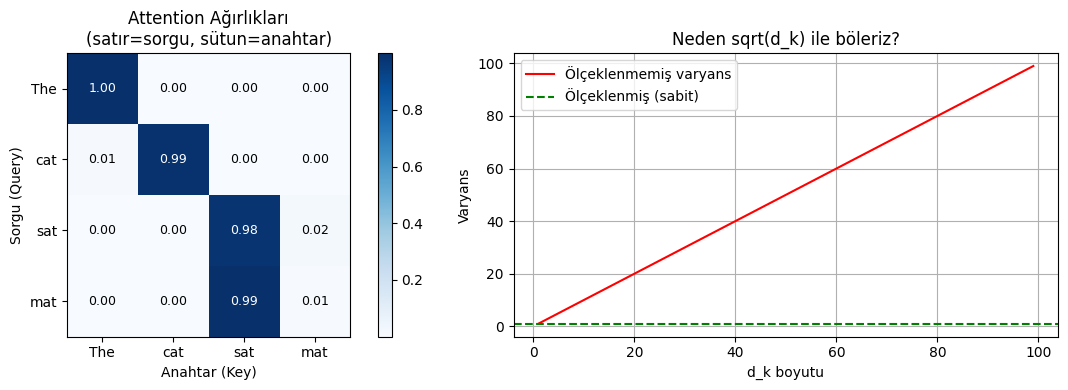

In [4]:
# Adım 4: Attention ağırlıklarıyla V'yi ağırlıklı topla
output = attention_weights @ V
print("Attention çıktısı shape:", output.shape)

# Görselleştir
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Attention haritası
im = ax1.imshow(attention_weights.detach().numpy(), cmap='Blues')
ax1.set_title("Attention Ağırlıkları\n(satır=sorgu, sütun=anahtar)")
ax1.set_xlabel("Anahtar (Key)")
ax1.set_ylabel("Sorgu (Query)")
ax1.set_xticks(range(4))
ax1.set_yticks(range(4))
ax1.set_xticklabels(['The', 'cat', 'sat', 'mat'])
ax1.set_yticklabels(['The', 'cat', 'sat', 'mat'])
plt.colorbar(im, ax=ax1)

# Değerleri hücrelere yaz
for i in range(4):
    for j in range(4):
        ax1.text(j, i, f'{attention_weights[i,j].item():.2f}',
                ha='center', va='center', fontsize=9,
                color='white' if attention_weights[i,j].item() > 0.5 else 'black')

# Ölçekleme etkisi
d_values = range(1, 100)
variances = [1.0 * d for d in d_values]
scaled = [1.0 for _ in d_values]

ax2.plot(d_values, variances, label='Ölçeklenmemiş varyans', color='red')
ax2.axhline(y=1, color='green', linestyle='--', label='Ölçeklenmiş (sabit)')
ax2.set_title("Neden sqrt(d_k) ile böleriz?")
ax2.set_xlabel("d_k boyutu")
ax2.set_ylabel("Varyans")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [5]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads  # Her kafa bu kadar boyut görür

        # Her kafa için ayrı Q, K, V ağırlıkları
        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)
        self.W_O = nn.Linear(d_model, d_model)  # Çıkış projeksiyonu

    def split_heads(self, x, batch_size):
        # (batch, seq_len, d_model) → (batch, num_heads, seq_len, d_k)
        x = x.view(batch_size, -1, self.num_heads, self.d_k)
        return x.transpose(1, 2)

    def forward(self, x, mask=None):
        batch_size = x.shape[0]

        # Q, K, V hesapla ve kafaları ayır
        Q = self.split_heads(self.W_Q(x), batch_size)
        K = self.split_heads(self.W_K(x), batch_size)
        V = self.split_heads(self.W_V(x), batch_size)

        # Scaled dot-product attention
        scores = Q @ K.transpose(-2, -1) / (self.d_k ** 0.5)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        weights = F.softmax(scores, dim=-1)
        attended = weights @ V

        # Kafaları birleştir
        attended = attended.transpose(1, 2).contiguous()
        attended = attended.view(batch_size, -1, self.d_model)

        return self.W_O(attended), weights

# Test et
d_model = 32
num_heads = 4
seq_len = 6
batch_size = 2

mha = MultiHeadAttention(d_model, num_heads)
x = torch.randn(batch_size, seq_len, d_model)
output, weights = mha(x)

print("Girdi shape:", x.shape)
print("Çıktı shape:", output.shape)
print("Attention weights shape:", weights.shape)
print(f"\n{num_heads} kafa, her biri {d_model//num_heads} boyutlu uzayda çalışıyor")
print("Her kafa farklı ilişki türlerini öğrenir!")

Girdi shape: torch.Size([2, 6, 32])
Çıktı shape: torch.Size([2, 6, 32])
Attention weights shape: torch.Size([2, 4, 6, 6])

4 kafa, her biri 8 boyutlu uzayda çalışıyor
Her kafa farklı ilişki türlerini öğrenir!


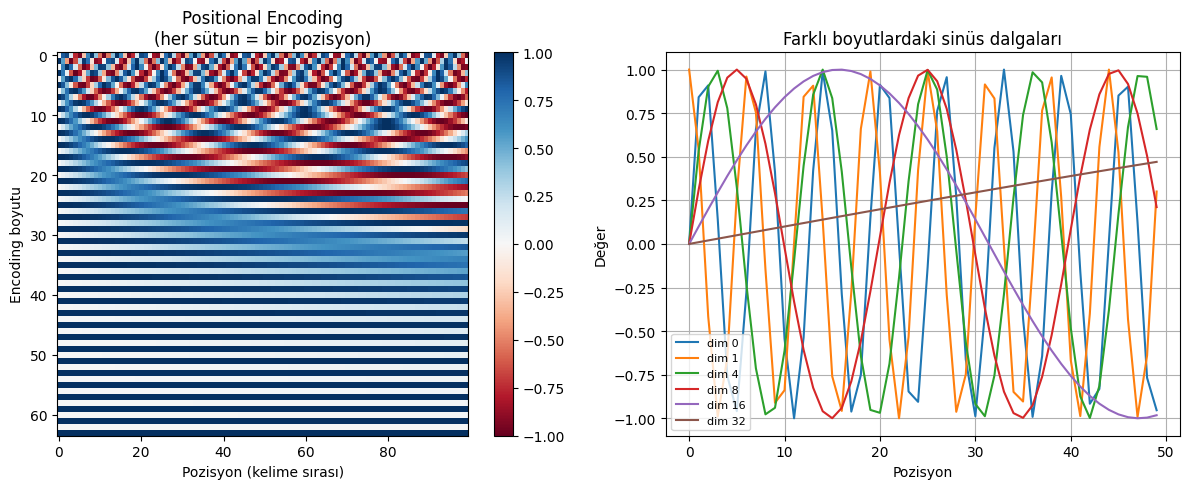

In [6]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model)
        )

        # Çift indeksler sin, tek indeksler cos
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

# Görselleştir
pe = PositionalEncoding(d_model=64)
dummy = torch.zeros(1, 100, 64)
encoding = pe(dummy).squeeze().detach().numpy()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(encoding.T, cmap='RdBu', aspect='auto')
plt.colorbar()
plt.title("Positional Encoding\n(her sütun = bir pozisyon)")
plt.xlabel("Pozisyon (kelime sırası)")
plt.ylabel("Encoding boyutu")

plt.subplot(1, 2, 2)
for dim in [0, 1, 4, 8, 16, 32]:
    plt.plot(encoding[:50, dim], label=f'dim {dim}')
plt.title("Farklı boyutlardaki sinüs dalgaları")
plt.xlabel("Pozisyon")
plt.ylabel("Değer")
plt.legend(fontsize=8)
plt.grid(True)

plt.tight_layout()
plt.show()

In [7]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super().__init__()

        # Multi-Head Attention
        self.attention = MultiHeadAttention(d_model, num_heads)

        # Feed Forward Network
        self.ff = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, d_model)
        )

        # Layer Normalization — Batch Norm'dan farklı, seq boyutunda normalize eder
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # 1. Self-attention + residual connection
        attended, weights = self.attention(x)
        x = self.norm1(x + self.dropout(attended))   # Add & Norm

        # 2. Feed forward + residual connection
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))     # Add & Norm

        return x, weights

class MiniTransformer(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, ff_dim, num_layers, max_len=512):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_len)
        self.layers = nn.ModuleList([
            TransformerBlock(d_model, num_heads, ff_dim)
            for _ in range(num_layers)
        ])
        self.fc_out = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        x = self.pos_encoding(x)

        all_weights = []
        for layer in self.layers:
            x, weights = layer(x)
            all_weights.append(weights)

        return self.fc_out(x), all_weights

# Modeli oluştur
vocab_size = 1000
d_model = 64
num_heads = 4
ff_dim = 256
num_layers = 2

model = MiniTransformer(vocab_size, d_model, num_heads, ff_dim, num_layers)

# Test et
batch_size = 2
seq_len = 10
x = torch.randint(0, vocab_size, (batch_size, seq_len))
output, weights = model(x)

total_params = sum(p.numel() for p in model.parameters())
print("Girdi shape:", x.shape)
print("Çıktı shape:", output.shape)
print(f"Toplam parametre: {total_params:,}")
print(f"\nMimarisi:")
print(f"  Vocab size: {vocab_size}")
print(f"  d_model: {d_model}")
print(f"  Attention heads: {num_heads}")
print(f"  FF dim: {ff_dim}")
print(f"  Katman sayısı: {num_layers}")

Girdi shape: torch.Size([2, 10])
Çıktı shape: torch.Size([2, 10, 1000])
Toplam parametre: 228,968

Mimarisi:
  Vocab size: 1000
  d_model: 64
  Attention heads: 4
  FF dim: 256
  Katman sayısı: 2


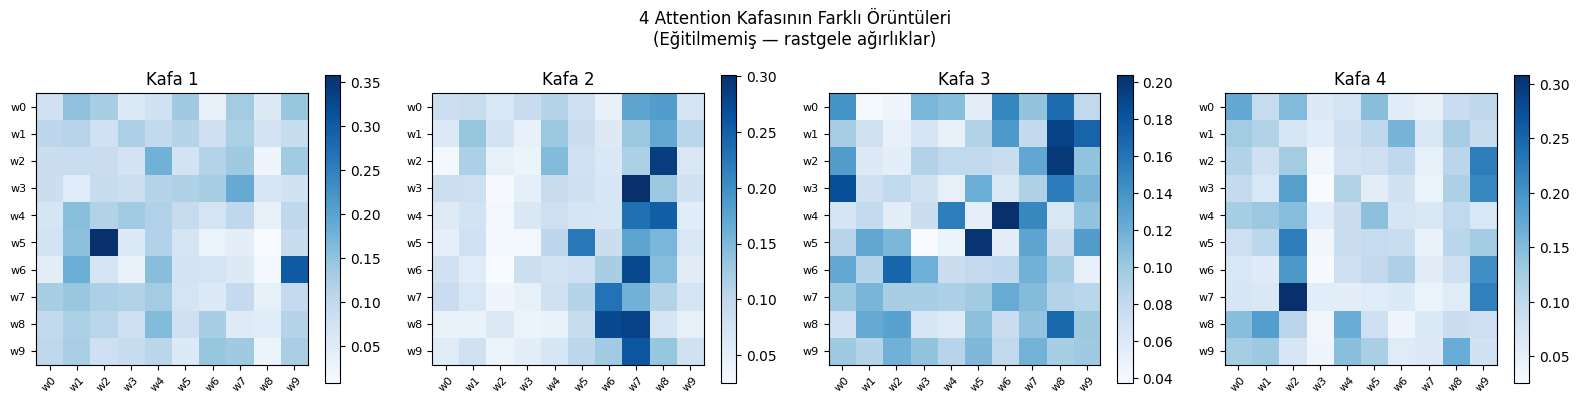


Her kafa farklı bir şeye odaklanmayı öğrenir:
Kafa 1 → örneğin sözdizimsel ilişkiler
Kafa 2 → örneğin anlamsal benzerlik
Kafa 3 → örneğin uzun menzilli bağımlılıklar
Kafa 4 → örneğin yerel bağlam


In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

kelimeler = [f"w{i}" for i in range(seq_len)]

for head in range(4):
    ax = axes[head]
    # İlk batch, ilk katman, ilgili kafa
    w = weights[0][0, head].detach().numpy()
    im = ax.imshow(w, cmap='Blues')
    ax.set_title(f"Kafa {head+1}")
    ax.set_xticks(range(seq_len))
    ax.set_yticks(range(seq_len))
    ax.set_xticklabels(kelimeler, rotation=45, fontsize=8)
    ax.set_yticklabels(kelimeler, fontsize=8)
    plt.colorbar(im, ax=ax)

plt.suptitle("4 Attention Kafasının Farklı Örüntüleri\n(Eğitilmemiş — rastgele ağırlıklar)", fontsize=12)
plt.tight_layout()
plt.show()
print("\nHer kafa farklı bir şeye odaklanmayı öğrenir:")
print("Kafa 1 → örneğin sözdizimsel ilişkiler")
print("Kafa 2 → örneğin anlamsal benzerlik")
print("Kafa 3 → örneğin uzun menzilli bağımlılıklar")
print("Kafa 4 → örneğin yerel bağlam")